# Regression polynomiale pour le controle de sterilisation

Ce notebook utilise un CSV industriel plus riche pour relier la temperature de sterilisation au taux de defauts. L'objectif est de montrer qu'un modele polynomial de degre 3 peut capturer une relation non lineaire et aider a definir une temperature cible de production.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Chargement du dataset industriel enrichi
# Le fichier CSV contient 60 observations de controle qualite sur la sterilisation.
data_path = Path("sterilisation_defauts.csv")
data = pd.read_csv(data_path)

print("Apercu du dataset:")
print(data.head())
print("\nDimensions du dataset:", data.shape)
print("\nStatistiques descriptives:")
print(data[["Temperature", "Taux_Defauts"]].describe())
print("\nNombre de temperatures distinctes:", data["Temperature"].nunique())

Apercu du dataset:
   Lot  Temperature  Taux_Defauts
0    1          108          21.0
1    2          108          20.6
2    3          108          20.8
3    4          108          21.2
4    5          110          18.8

Dimensions du dataset: (60, 3)

Statistiques descriptives:
       Temperature  Taux_Defauts
count    60.000000     60.000000
mean    121.000000     13.155000
std       7.854611      5.068361
min     108.000000      6.000000
25%     114.000000      8.350000
50%     121.000000     12.700000
75%     128.000000     17.575000
max     134.000000     22.200000

Nombre de temperatures distinctes: 15


### Description du code
Cette cellule charge le fichier CSV industriel, affiche un apercu, les dimensions, puis des statistiques descriptives sur la temperature et le taux de defauts.

### Interpretation des resultats
Le jeu de donnees est structure et exploitable: on verifie le volume, la variabilite et les plages de valeurs avant l'apprentissage. Cette verification evite de construire un modele sur des donnees incompletes ou incoherentes.

In [10]:
# Variables
X = data[["Temperature"]].values
y = data["Taux_Defauts"].values

degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Split train/test (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Transformation polynomiale
X_train_poly = poly.fit_transform(X_train_raw)
X_test_poly = poly.transform(X_test_raw)

print(f"Taille train: {len(X_train_raw)}, Taille test: {len(X_test_raw)}")
print(f"Hyperparametre principal: degree = {degree}")
print("Nombre d'iterations: non applicable avec LinearRegression (solution analytique)")

Taille train: 48, Taille test: 12
Hyperparametre principal: degree = 3
Nombre d'iterations: non applicable avec LinearRegression (solution analytique)


### Description du code
La cellule prepare la variable cible, separe train/test, et applique la transformation polynomiale de degre 3 (hyperparametre principal).

### Interpretation des resultats
La separation train/test permet d'evaluer la generalisation. Le degre 3 est pertinent pour capter une relation non lineaire, et l'absence d'iterations est normale ici car `LinearRegression` utilise une solution analytique.

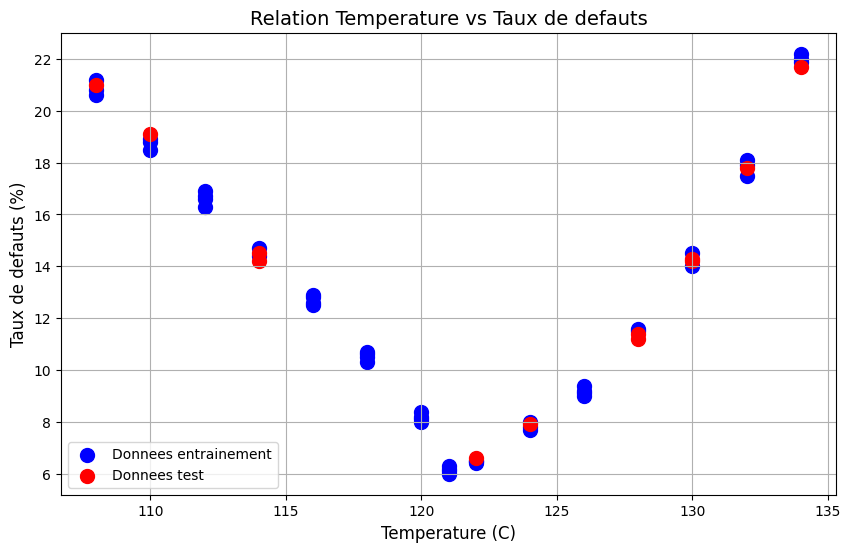

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_raw, y_train, color='blue', label='Donnees entrainement', s=100)
plt.scatter(X_test_raw, y_test, color='red', label='Donnees test', s=100)
plt.xlabel('Temperature (C)', fontsize=12)
plt.ylabel('Taux de defauts (%)', fontsize=12)
plt.title('Relation Temperature vs Taux de defauts', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### Description du code
Cette cellule trace les points train et test sur un nuage de dispersion pour visualiser la relation entre temperature et defauts.

### Interpretation des resultats
La couverture des deux groupes est coherente sur la plage de temperature: il n'y a pas de decoupage biaise. Le nuage montre deja une forme courbe, ce qui justifie l'usage d'un modele polynomial.

In [12]:
# Entrainement du modele polynomial de degre 3
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Coefficients
print("Coefficients du modele:")
print(f"Intercept = {model.intercept_:.4f}")
print(f"c1 (x) = {model.coef_[0]:.4f}")
print(f"c2 (x^2) = {model.coef_[1]:.4f}")
print(f"c3 (x^3) = {model.coef_[2]:.6f}")
print("Interpretation: le terme lineaire corrige la pente globale, le terme quadratique porte la courbure, et le terme cubique capte l'asymetrie de la courbe.")

Coefficients du modele:
Intercept = -3402.6242
c1 (x) = 95.4322
c2 (x^2) = -0.8754
c3 (x^3) = 0.002641
Interpretation: le terme lineaire corrige la pente globale, le terme quadratique porte la courbure, et le terme cubique capte l'asymetrie de la courbe.


### Description du code
Le modele polynomial est entraine puis ses coefficients (termes lineaire, quadratique, cubique) sont affiches.

### Interpretation des resultats
Les coefficients decrivent la forme de la courbe: pente globale, courbure, et asymetrie. Ensemble, ils traduisent un comportement process non lineaire plus realiste qu'une droite simple.

In [13]:
# Predictions
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# Metriques
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n=== RESULTATS ===")
print(f"MSE Train: {mse_train:.4f}")
print(f"MSE Test: {mse_test:.4f}")
print(f"R2 Train: {r2_train:.4f}")
print(f"R2 Test: {r2_test:.4f}")
print("Interpretation: une MSE faible et un R2 proche de 1 signifient que le modele reproduit bien la relation non lineaire sans surapprentissage excessif.")


=== RESULTATS ===
MSE Train: 0.7895
MSE Test: 0.6174
R2 Train: 0.9693
R2 Test: 0.9707
Interpretation: une MSE faible et un R2 proche de 1 signifient que le modele reproduit bien la relation non lineaire sans surapprentissage excessif.


### Description du code
La cellule calcule les predictions train/test puis les metriques de performance: MSE et R2.

### Interpretation des resultats
Une MSE faible et un R2 eleve, surtout en test, indiquent que le modele reproduit bien la dynamique du procede sans surapprentissage excessif. C'est l'indicateur cle pour valider la qualite predictive.

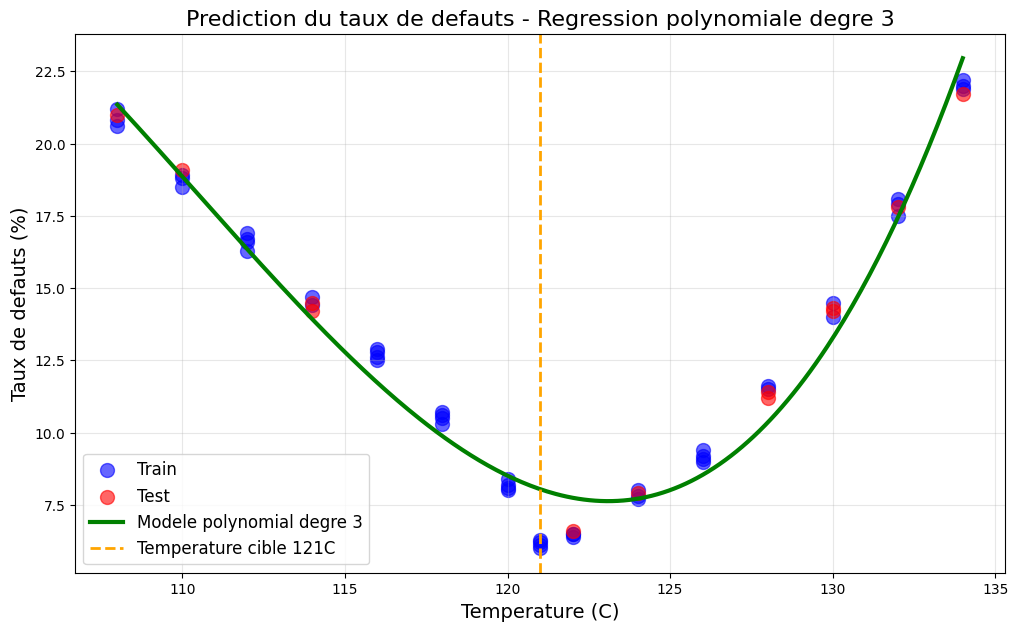

In [14]:
# Courbe de prediction
X_range = np.linspace(108, 134, 300).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

plt.figure(figsize=(12, 7))
plt.scatter(X_train_raw, y_train, color='blue', s=100, label='Train', alpha=0.6)
plt.scatter(X_test_raw, y_test, color='red', s=100, label='Test', alpha=0.6)
plt.plot(X_range, y_range_pred, color='green', linewidth=3, label='Modele polynomial degre 3')
plt.axvline(x=121, color='orange', linestyle='--', linewidth=2, label='Temperature cible 121C')
plt.xlabel('Temperature (C)', fontsize=14)
plt.ylabel('Taux de defauts (%)', fontsize=14)
plt.title('Prediction du taux de defauts - Regression polynomiale degre 3', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Description du code
Cette cellule construit la courbe de prediction sur une plage continue de temperatures et superpose train/test avec une ligne de reference a 121C.

### Interpretation des resultats
La courbe permet d'identifier visuellement la zone de minimum des defauts. Cette zone correspond a une consigne process candidate pour reduire les rebuts.

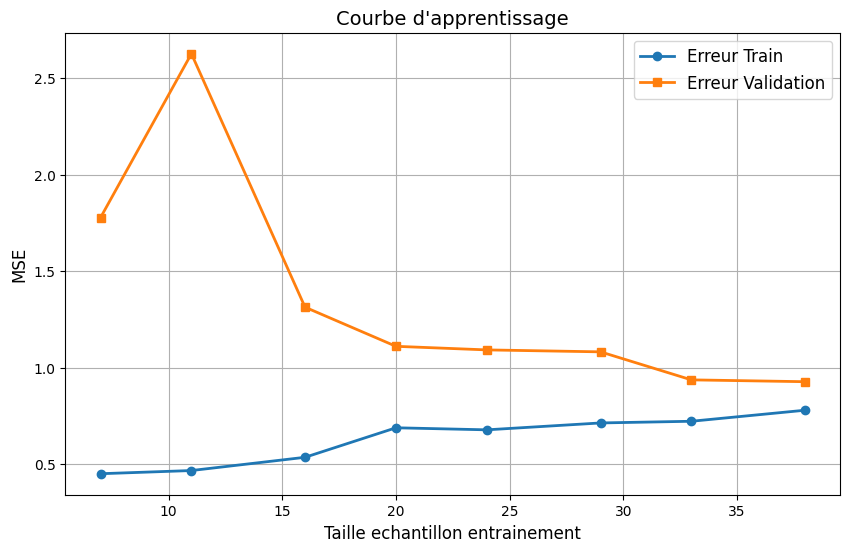

Interpretation: si les deux courbes convergent et restent proches, le modele generalise correctement; un ecart fort indiquerait plutot un surapprentissage ou un sous-apprentissage.


In [15]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X_train_poly,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.2, 1.0, 8),
    scoring='neg_mean_squared_error'
)

train_mean = -train_scores.mean(axis=1)
val_mean = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Erreur Train', marker='o', linewidth=2)
plt.plot(train_sizes, val_mean, label='Erreur Validation', marker='s', linewidth=2)
plt.xlabel('Taille echantillon entrainement', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Courbe d\'apprentissage', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

print('Interpretation: si les deux courbes convergent et restent proches, le modele generalise correctement; un ecart fort indiquerait plutot un surapprentissage ou un sous-apprentissage.')

### Description du code
La cellule calcule et trace une courbe d'apprentissage (erreur train vs validation) selon la taille de l'echantillon.

### Interpretation des resultats
Si les deux courbes convergent avec un ecart limite, le modele generalise correctement. Un ecart persistant signalerait un risque de surapprentissage ou de sous-apprentissage.

In [16]:
# Trouver le minimum de la courbe (temperature optimale)
min_idx = np.argmin(y_range_pred)
temp_optimale = X_range[min_idx][0]
defaut_min = y_range_pred[min_idx]

print("\n=== OPTIMISATION ===")
print(f"Temperature optimale predite: {temp_optimale:.1f}C")
print(f"Taux de defauts minimal: {defaut_min:.2f}%")
print("Interpretation: cette temperature correspond au point de consigne industriel qui minimise les defauts de sterilisation tout en gardant le process stable.")


=== OPTIMISATION ===
Temperature optimale predite: 123.1C
Taux de defauts minimal: 7.63%
Interpretation: cette temperature correspond au point de consigne industriel qui minimise les defauts de sterilisation tout en gardant le process stable.


### Description du code
La cellule recherche le minimum de la courbe predite pour extraire la temperature optimale et le taux de defauts minimal associe.

### Interpretation des resultats
Ce resultat transforme le modele en decision industrielle: il fournit une consigne argumentee pour piloter la sterilisation et reduire les non-conformites.